# Maximum correlation long/short split

I split a universe of assets into two equal groups, long and short, so that the sum of one side tracks the sum of the other as closely as possible. The method relaxes the problem into a spectral start, then runs a swap search in the style of Kernighan and Lin on top of it, repeated from a bunch of different starting points and kept as a library. Below I check the solver against brute force at $n=20$, then check whether the split it finds actually holds up a year later.

Everything here loads from `results/tables/`, written by `main.py`, except the brute force, one walk forward pair, and the extras section, which run live in this notebook. Restart and run all works end to end.

In [1]:
import sys
sys.path.insert(0, "scripts")
sys.path.insert(0, ".")

import math
import time
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

pd.set_option("display.width", 150)

from preprocessing import load_returns, chrono_split, vol_normalize
from objective import precompute_P, rho_exact, rho_exact_batch, basket_correlation

cfg = yaml.safe_load(open("config.yaml"))
TABLES = "results/tables"

df = load_returns(cfg["data_path"], cfg["data_type"], cfg["min_obs"])
names = list(df.columns)
X = df.to_numpy()
X_tr, X_va = chrono_split(X, cfg["train_fraction"])
X_tr, X_va = vol_normalize(X_tr, X_va)
C_tr = np.corrcoef(X_tr, rowvar=False)
pst_tr = precompute_P(X_tr)
best_split = np.load(f"{TABLES}/best_split.npy")

print(f"{len(names)} assets x {len(df)} daily returns, {df.index[0].date()} -> {df.index[-1].date()}")
print("6 FX, 9 equity indices, 5 commodities. Log returns, vol normalized on train, chronological split.")

20 assets x 6859 daily returns, 2000-01-05 -> 2026-05-06
6 FX, 9 equity indices, 5 commodities. Log returns, vol normalized on train, chronological split.


## Objective

I define $P = X\mathbf{1}$ as the pooled return, everything summed together, and $D = Xs$ as the signed spread between the two baskets. With $q=\operatorname{var}(P)$, $v=\operatorname{var}(D)$, $u=\operatorname{cov}(P,D)$, the correlation between the two baskets works out to:

$$\rho(s) = \frac{q - v}{\sqrt{(q+v)^2 - 4u^2}}.$$

The returns are vol normalized, so $v$ works out to $s^\top C s$, and minimizing that is the same thing as maximizing $\rho$. I still score everything on the exact $\rho$ formula above, but the search itself runs on $s^\top C s$, since the swap gains there are closed form and I'd rather not recompute $\rho$ from scratch on every candidate swap.

In [2]:
pd.DataFrame({
    "source": ["closed form", "corrcoef of the two basket sums", "library.csv"],
    "rho_train": [rho_exact(X_tr, best_split, pst_tr),
                  basket_correlation(X_tr, best_split),
                  pd.read_csv(f"{TABLES}/library.csv")["rho_train"].iloc[0]],
}).round(6)

,source,rho_train
0,closed form,0.879404
1,corrcoef of the two basket sums,0.879404
2,library.csv,0.879404


All three numbers below match: the closed form identity, a plain correlation of the two basket sums, and the value already sitting in `library.csv`. If I'd gotten the algebra wrong, this is exactly where it would show up.

## Method

I start by relaxing the $\pm 1$ constraint on $s$ and just minimizing $s^\top C s$ over balanced unit vectors. Under $\mathbf{1}^\top s = 0$ and $\lVert s\rVert^2 = n$ that's a Rayleigh quotient, so the answer comes straight out as the eigenvector of the smallest non trivial eigenvalue of $PCP$. Rounding it at the median turns that back into a balanced $\pm 1$ start.

From there I run a swap search in the style of Kernighan and Lin. Take a green name and a red name and swap them, and the gain from that one swap is closed form,

$$\Delta_{ij} = -4\,(s_i g_i + s_j g_j) + 4\,(C_{ii} + C_{jj}) - 8\,C_{ij}, \qquad g = Cs,$$

and since $g$ updates incrementally, a pass through the whole set is cheap. The trick is not stopping at the first swap that fails to help. Each name gets locked once it's been swapped so nothing flips back and forth, and the score is allowed to get worse for a few more swaps before anything is decided. Only at the end does it look back down that chain and keep whichever prefix actually left things better than where it started, which is what lets it climb out of a hole a single greedy swap would just sit in.

One spectral start on its own isn't enough, so I run a batch of them: spectral, PCA, random, bottom eigenspace draws. Each one gets refined the same way, scored out of sample, then filtered for diversity, so the library ends up with a handful of genuinely different splits instead of ten copies of whichever one happened to win first.

In [3]:
c20 = math.comb(19, 9)
c180 = math.comb(179, 89)
print(f"n=20 : {c20:,} balanced splits")
print(f"n=180: {c180:.3e} balanced splits  (~{c180 / c20:.0e}x)")

n=20 : 92,378 balanced splits
n=180: 4.551e+52 balanced splits  (~5e+47x)


At $n=20$ I can check everything against brute force, but the universe is correlated enough that most splits already score high. $n=180$ is the real test.

## The split

Training gives $\rho_{\text{train}} = 0.8794$; on the held out window it's $\rho_{\text{valid}} = 0.8574$.

In [4]:
green = [names[i] for i in np.where(best_split == 1)[0]]
red = [names[i] for i in np.where(best_split == -1)[0]]
pairs = [("WTI", "BRENT"), ("GOLD", "SILVER"), ("SPX", "NDX"),
         ("DAX", "CAC"), ("NKY", "HSI"), ("EURUSD", "GBPUSD")]
opp = [best_split[names.index(a)] != best_split[names.index(b)] for a, b in pairs]

display(pd.DataFrame({"green (long)": green, "red (short)": red}))
print("natural hedge pairs on opposite sides:",
      f"{sum(opp)}/{len(pairs)}", "->", ", ".join(f"{a}/{b}" for a, b in pairs))

,green (long),red (short)
0,GBPUSD,EURUSD
1,USDJPY,USDCHF
2,NDX,AUDUSD
3,DAX,USDCAD
4,UKX,SPX
5,IBEX,CAC
6,HSI,FTSEMIB
7,GOLD,NKY
8,BRENT,SILVER
9,NATGAS,WTI


natural hedge pairs on opposite sides: 6/6 -> WTI/BRENT, GOLD/SILVER, SPX/NDX, DAX/CAC, NKY/HSI, EURUSD/GBPUSD


Every hedge pair ends up split across the two baskets. The solver only ever sees $C$, never the asset classes, so nothing pushed it there on purpose.

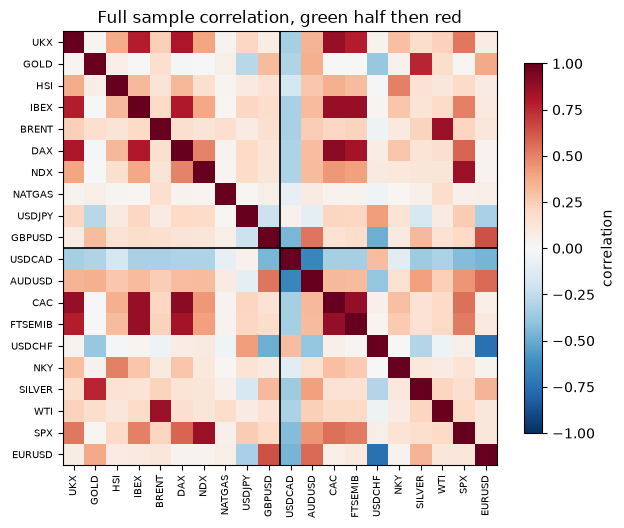

In [5]:
order = np.argsort(-best_split)
half = len(names) // 2
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(np.corrcoef(X, rowvar=False)[np.ix_(order, order)], vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(names)))
ax.set_xticklabels([names[i] for i in order], rotation=90, fontsize=7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([names[i] for i in order], fontsize=7)
ax.axhline(half - 0.5, color="k", lw=1.2)
ax.axvline(half - 0.5, color="k", lw=1.2)
ax.set_title("Full sample correlation, green half then red")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
plt.show()

The cut runs through the equity block and the metal and energy pairs instead of putting a whole asset class on one side.

## Brute force check

$n=20$ is small enough to enumerate every balanced split, so I can check exactly how close the heuristic gets to the real optimum.

In [6]:
from bruteforce_check import brute_force_optimum
from solvers import spectral_split, kl_refine

t0 = time.perf_counter()
bf_rho, bf_s, n_combos = brute_force_optimum(X_tr, pst_tr)
bf_secs = time.perf_counter() - t0
single_rho = rho_exact(X_tr, kl_refine(C_tr, spectral_split(C_tr), X_tr), pst_tr)
lib_best = pd.read_csv(f"{TABLES}/library.csv")["rho_train"].max()

print(f"brute force        : {n_combos:,} splits in {bf_secs:.1f}s, optimum = {bf_rho:.6f}")
print(f"library best       : {lib_best:.6f}   gap {bf_rho - lib_best:.1e}")
print(f"single spectral+KL : {single_rho:.6f}   gap {bf_rho - single_rho:.1e}")

brute force        : 92,378 splits in 1.0s, optimum = 0.879404
library best       : 0.879404   gap 4.4e-16
single spectral+KL : 0.863549   gap 1.6e-02


The library lands on the global optimum. A single spectral+KL start stops 1.6e-2 short, which is why I run many starts instead of one. At $n=180$ there's no true optimum to check against, so instead I'd look at how many different starting points converge on the same split.

## Walk forward persistence

I optimize the split on year $t-1$, freeze it, then score it on year $t$, data it never saw during training. To know whether that score means anything, I compare it to a Monte Carlo of random balanced splits scored on that same year $t$. One pair below is built live, then all 25 years.

In [7]:
from walkforward import yearly_blocks
from solvers import random_balanced

blocks = yearly_blocks(df.index)
(yr_prev, idx_prev), (yr_next, idx_next) = blocks[-2], blocks[-1]

Xp = X[idx_prev]
Xp = Xp / np.where(Xp.std(0, ddof=1) == 0, 1.0, Xp.std(0, ddof=1))
Cp = np.corrcoef(Xp, rowvar=False)
s_frozen = kl_refine(Cp, spectral_split(Cp), Xp)

Xn = X[idx_next]
Xn = Xn / np.where(Xn.std(0, ddof=1) == 0, 1.0, Xn.std(0, ddof=1))
pst_n = precompute_P(Xn)
rho_out = rho_exact(Xn, s_frozen, pst_n)

rng_live = np.random.default_rng(cfg["seed"])
S_rand = np.stack([random_balanced(Xn.shape[1], rng_live) for _ in range(cfg["mc_samples"])], axis=1)
null_live = rho_exact_batch(Xn, S_rand, pst_n)

print(f"optimize on {yr_prev}      rho_train = {rho_exact(Xp, s_frozen):.4f}")
print(f"freeze, score on {yr_next}  rho_next  = {rho_out:.4f}")
print(f"null on {yr_next}           mean {null_live.mean():.4f}, sd {null_live.std(ddof=1):.4f}")
print(f"-> percentile = {float((null_live < rho_out).mean()):.3f}")

optimize on 2024      rho_train = 0.8797
freeze, score on 2025  rho_next  = 0.8668
null on 2025           mean 0.6232, sd 0.1273
-> percentile = 0.997


The split was picked without seeing 2025 at all, and it still lands in the right tail of that year's null.

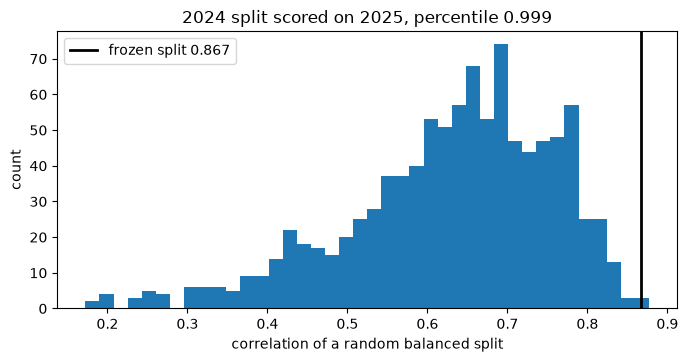

In [8]:
wf = pd.read_csv(f"{TABLES}/walkforward.csv")
last_null = np.load(f"{TABLES}/last_year_null.npy")
last = wf.iloc[-1]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(last_null, bins=40)
ax.axvline(last["rho_next"], color="k", lw=2, label=f"frozen split {last['rho_next']:.3f}")
ax.set_xlabel("correlation of a random balanced split")
ax.set_ylabel("count")
ax.set_title(f"{int(last['train_year'])} split scored on {int(last['test_year'])}, "
             f"percentile {last['percentile']:.3f}")
ax.legend()
plt.show()

The null is left skewed: in a universe this correlated, even a random split tends to score fairly high. That's also why I use the percentile here instead of a z, since the null is nowhere near normal.

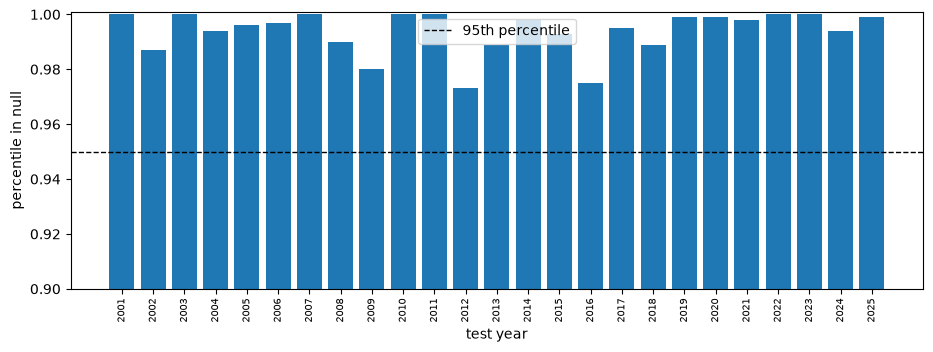

year pairs        : 25
years pct >= 0.95 : 25/25
min percentile    : 0.973


In [9]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(range(len(wf)), wf["percentile"])
ax.axhline(0.95, ls="--", color="k", lw=1, label="95th percentile")
ax.set_xticks(range(len(wf)))
ax.set_xticklabels(wf["test_year"], rotation=90, fontsize=7)
ax.set_xlabel("test year")
ax.set_ylabel("percentile in null")
ax.set_ylim(0.9, 1.001)
ax.legend()
plt.show()

print(f"year pairs        : {len(wf)}")
print(f"years pct >= 0.95 : {int((wf['percentile'] >= 0.95).sum())}/{len(wf)}")
print(f"min percentile    : {wf['percentile'].min():.3f}")

All 25 years clear the 95th percentile, worst case 0.973, so it doesn't really matter where I draw that line. In sample and frozen out of sample $\rho$ stay close too, so this isn't one lucky year. At $n=20$ the effect is mild by construction anyway; $n=180$ is where it should really show up.

## Extras

These are extra checks on top of the walk forward test above, meant to rule out two specific worries: that a smarter search algorithm would have found something better, and that the result depends on which random splits I happened to compare against. Both are optional, gated behind config flags, and the main pipeline runs fine without them.

I wanted a second opinion from a completely different kind of search, so I tried simulated bifurcation. It solves the same kind of problem, assign each name a $+1$ or $-1$ so a quadratic score comes out as small as possible, but it comes from physics simulation rather than anything Kernighan and Lin style, and it has no built in notion of keeping the two groups the same size. So I add a penalty term that pushes it toward balance, patch up whatever imbalance is left over with a repair step, and then run the same swap based polish on the result that the library uses. That last step means it's not a fully independent check, since it ends up in the same kind of local search either way, but it starts from a completely different place than anything in the library.

In [10]:
sb = pd.read_csv(f"{TABLES}/sb_benchmark.csv")
sb["hits"] = np.isclose(sb["best_rho_train"], bf_rho, atol=1e-6)
print(sb.groupby("lam_mult").agg(best_rho_train=("best_rho_train", "max"),
                                 hit_rate=("hits", "mean"),
                                 mean_seconds=("seconds", "mean")).round(4).to_string())

try:
    from sb_solver import _sb_agents_finals
    finals = _sb_agents_finals(C_tr, X_tr, float(np.mean(np.abs(C_tr))), 128, "discrete", False, seed=0)
    sb_best = max(rho_exact(X_tr, s, pst_tr) for s in finals)
    print(f"\nlive SB, {len(finals)} agents: {sb_best:.6f}  reaches optimum: {abs(sb_best - bf_rho) < 1e-6}")
except ImportError:
    print("\ntorch / simulated_bifurcation not installed, saved benchmark above")

          best_rho_train  hit_rate  mean_seconds
lam_mult                                        
0.25              0.8794       1.0        0.4797
0.50              0.8794       1.0        0.2587
1.00              0.8794       1.0        0.2555
2.00              0.8794       1.0        0.3409



live SB, 128 agents: 0.879404  reaches optimum: True


Across every penalty setting I tried, it lands on the exact same optimum as the library, never better. Different starting point, same answer.

I also checked two more definitions of what "random" means, on top of the random splits used in the walk forward test. Label permutation keeps the same 10 versus 10 shape but randomly reshuffles which asset lands in which spot, so it's really asking the same question as a random split: does it matter which specific assets end up together? The block bootstrap asks something else. It keeps my actual split exactly as found and instead scrambles the order of the days in the holdout window, in chunks of 21 trading days at a time rather than single days, since daily returns carry some memory from the day before and shuffling single days would erase that. This tells me how much my split's own score wobbles just from a different ordering of the same days, not whether some other split would have done just as well.

In [11]:
from extra_nulls import extra_nulls

rng = np.random.default_rng(cfg["seed"])
pst_va = precompute_P(X_va)
rho_va = rho_exact(X_va, best_split, pst_va)
n_ex = cfg["mc_samples"]

S = np.stack([random_balanced(X_va.shape[1], rng) for _ in range(n_ex)], axis=1)
en = extra_nulls(X_va, best_split, n_ex, cfg.get("block_len", 21), rng)

rows = [{"null model": nm, "null_mean": float(v.mean()), "null_sd": float(v.std(ddof=1)),
         "percentile": float((v < rho_va).mean())}
        for nm, v in [("random split", rho_exact_batch(X_va, S, pst_va)),
                      ("label permutation", en["label_permutation"]),
                      ("block bootstrap 21d", en["block_bootstrap"])]]
print(f"held out rho of the frozen split: {rho_va:.4f}\n")
pd.DataFrame(rows).round(4)

held out rho of the frozen split: 0.8574



,null model,null_mean,null_sd,percentile
0,random split,0.6609,0.0913,0.999
1,label permutation,0.6648,0.0963,0.996
2,block bootstrap 21d,0.8518,0.0266,0.566


The frozen split beats almost every random split and almost every reshuffled labeling, landing at the 99.9th and 99.6th percentile. The block bootstrap gives a different kind of answer, because it never changes which assets are grouped together: its range of outcomes is much narrower (sd 0.027) and sits right on top of my actual score (mean 0.852 versus 0.857). A percentile of 0.566 there just means my score looks like an ordinary result within that narrow range, which is what I want to see, it means the number isn't an artifact of one lucky sequence of days.

There's also a split half clustering validation sitting in `scripts/clustering.py`, which checks something else again: whether clustering each half separately turns up the same groups. At ten names a side it's underpowered, it didn't separate from a random split, so I've parked it until there's a bigger universe to test it on.

## References

Kernighan and Lin (1970). Mantegna (1999), correlation distance. Goto, Tatsumura and Dixon (2019), simulated bifurcation. Kunsch (1989), moving block bootstrap.